# 04 — Time Series Forecasting
## Smart Expense Intelligence Dashboard
**Goal:** Use Facebook Prophet to forecast next 3 months of total spend and per-category spend. Export forecast CSVs for Power BI.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../exports', exist_ok=True)

# Load clean data
df = pd.read_csv('../data/clean_transactions.csv', parse_dates=['date'])

# Remove incomplete October
df = df[df['month'] < 10]

print(f"✅ Data loaded: {df.shape}")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")

✅ Data loaded: (47606, 18)
   Date range: 2023-01-01 → 2023-09-30


In [3]:
# Prophet requires exactly two columns: ds (date) and y (value)
daily_spend = (df.groupby('date')['transaction_amount']
               .sum()
               .reset_index())

daily_spend.columns = ['ds', 'y']
daily_spend = daily_spend.sort_values('ds').reset_index(drop=True)

print(f"Daily spend data prepared")
print(f"Rows     : {len(daily_spend)}")
print(f"Date range: {daily_spend['ds'].min().date()} → {daily_spend['ds'].max().date()}")
print(f"Avg daily spend : ₹{daily_spend['y'].mean():,.2f}")
print(f"Max daily spend : ₹{daily_spend['y'].max():,.2f}")
print(f"Min daily spend : ₹{daily_spend['y'].min():,.2f}")
daily_spend.head()

Daily spend data prepared
Rows     : 273
Date range: 2023-01-01 → 2023-09-30
Avg daily spend : ₹77,055.31
Max daily spend : ₹115,721.05
Min daily spend : ₹46,868.41


,ds,y
0,2023-01-01,65531.45
1,2023-01-02,78895.54
2,2023-01-03,60747.61
3,2023-01-04,93617.86
4,2023-01-05,87047.84


In [4]:
# Initialize and train model
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.95
)

model.fit(daily_spend)

# Create future dataframe — 90 days ahead (3 months)
future = model.make_future_dataframe(periods=90)

# Generate forecast
forecast = model.predict(future)

print(f"✅ Prophet model trained and forecast generated")
print(f"   Training period : {daily_spend['ds'].min().date()} → {daily_spend['ds'].max().date()}")
print(f"   Forecast end    : {forecast['ds'].max().date()}")
print(f"\nForecast columns: {['ds','yhat','yhat_lower','yhat_upper']}")
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(5)

12:37:27 - cmdstanpy - INFO - Chain [1] start processing
12:37:27 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained and forecast generated
   Training period : 2023-01-01 → 2023-09-30
   Forecast end    : 2023-12-29

Forecast columns: ['ds', 'yhat', 'yhat_lower', 'yhat_upper']


,ds,yhat,yhat_lower,yhat_upper
358,2023-12-25,80055.391975,57959.950595,101150.798621
359,2023-12-26,74165.132798,54599.101201,94813.223483
360,2023-12-27,78649.786009,56453.402197,98948.449307
361,2023-12-28,78871.035015,58023.090644,99791.649094
362,2023-12-29,76773.074841,56848.600493,97459.213120


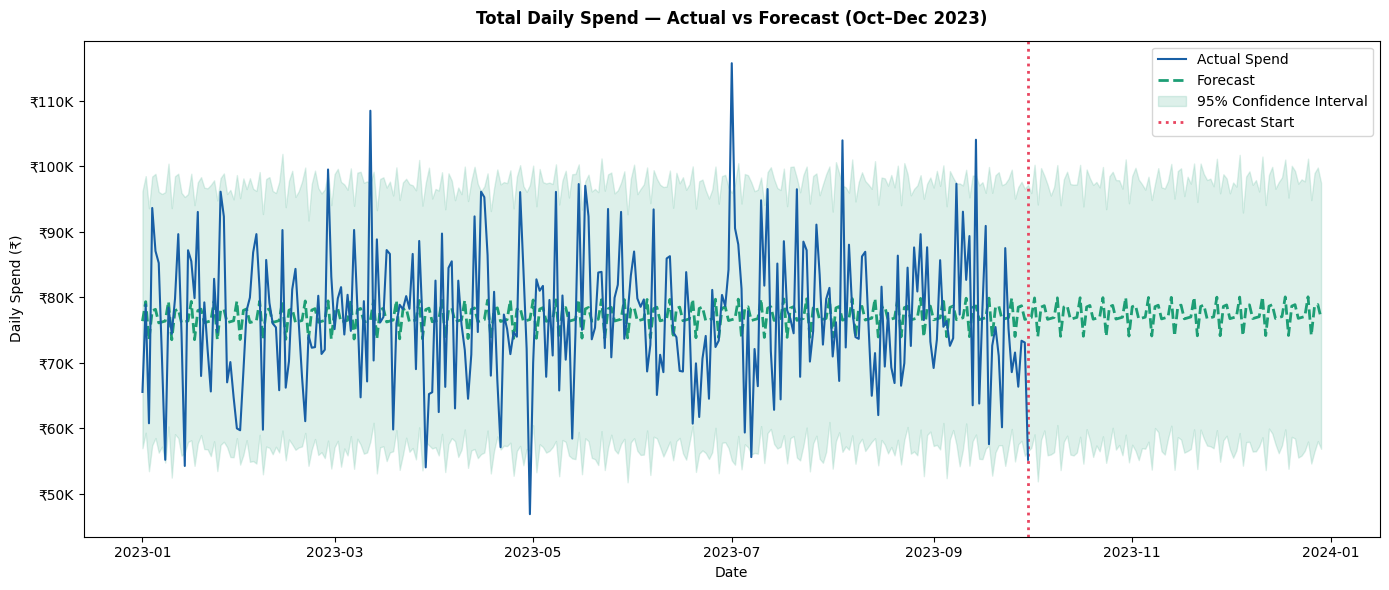

✅ Chart saved → screenshots/09_total_forecast.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual
ax.plot(daily_spend['ds'], daily_spend['y'], 
        color='#185FA5', linewidth=1.5, label='Actual Spend', zorder=3)

# Plot forecast
forecast_only = forecast[forecast['ds'] > daily_spend['ds'].max()]
ax.plot(forecast['ds'], forecast['yhat'], 
        color='#1D9E75', linewidth=2, linestyle='--', label='Forecast')

# Confidence interval
ax.fill_between(forecast['ds'], 
                forecast['yhat_lower'], 
                forecast['yhat_upper'],
                alpha=0.15, color='#1D9E75', label='95% Confidence Interval')

# Vertical line at forecast start
ax.axvline(x=daily_spend['ds'].max(), color='#E94560', 
           linestyle=':', linewidth=2, label='Forecast Start')

ax.set_title('Total Daily Spend — Actual vs Forecast (Oct–Dec 2023)', 
             fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Spend (₹)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))
ax.legend()

plt.tight_layout()
plt.savefig('../screenshots/09_total_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → screenshots/09_total_forecast.png")

12:37:28 - cmdstanpy - INFO - Chain [1] start processing
12:37:28 - cmdstanpy - INFO - Chain [1] done processing
12:37:29 - cmdstanpy - INFO - Chain [1] start processing


✅ Travel model trained


12:37:29 - cmdstanpy - INFO - Chain [1] done processing
12:37:29 - cmdstanpy - INFO - Chain [1] start processing


✅ Electronics model trained


12:37:29 - cmdstanpy - INFO - Chain [1] done processing


✅ Market model trained


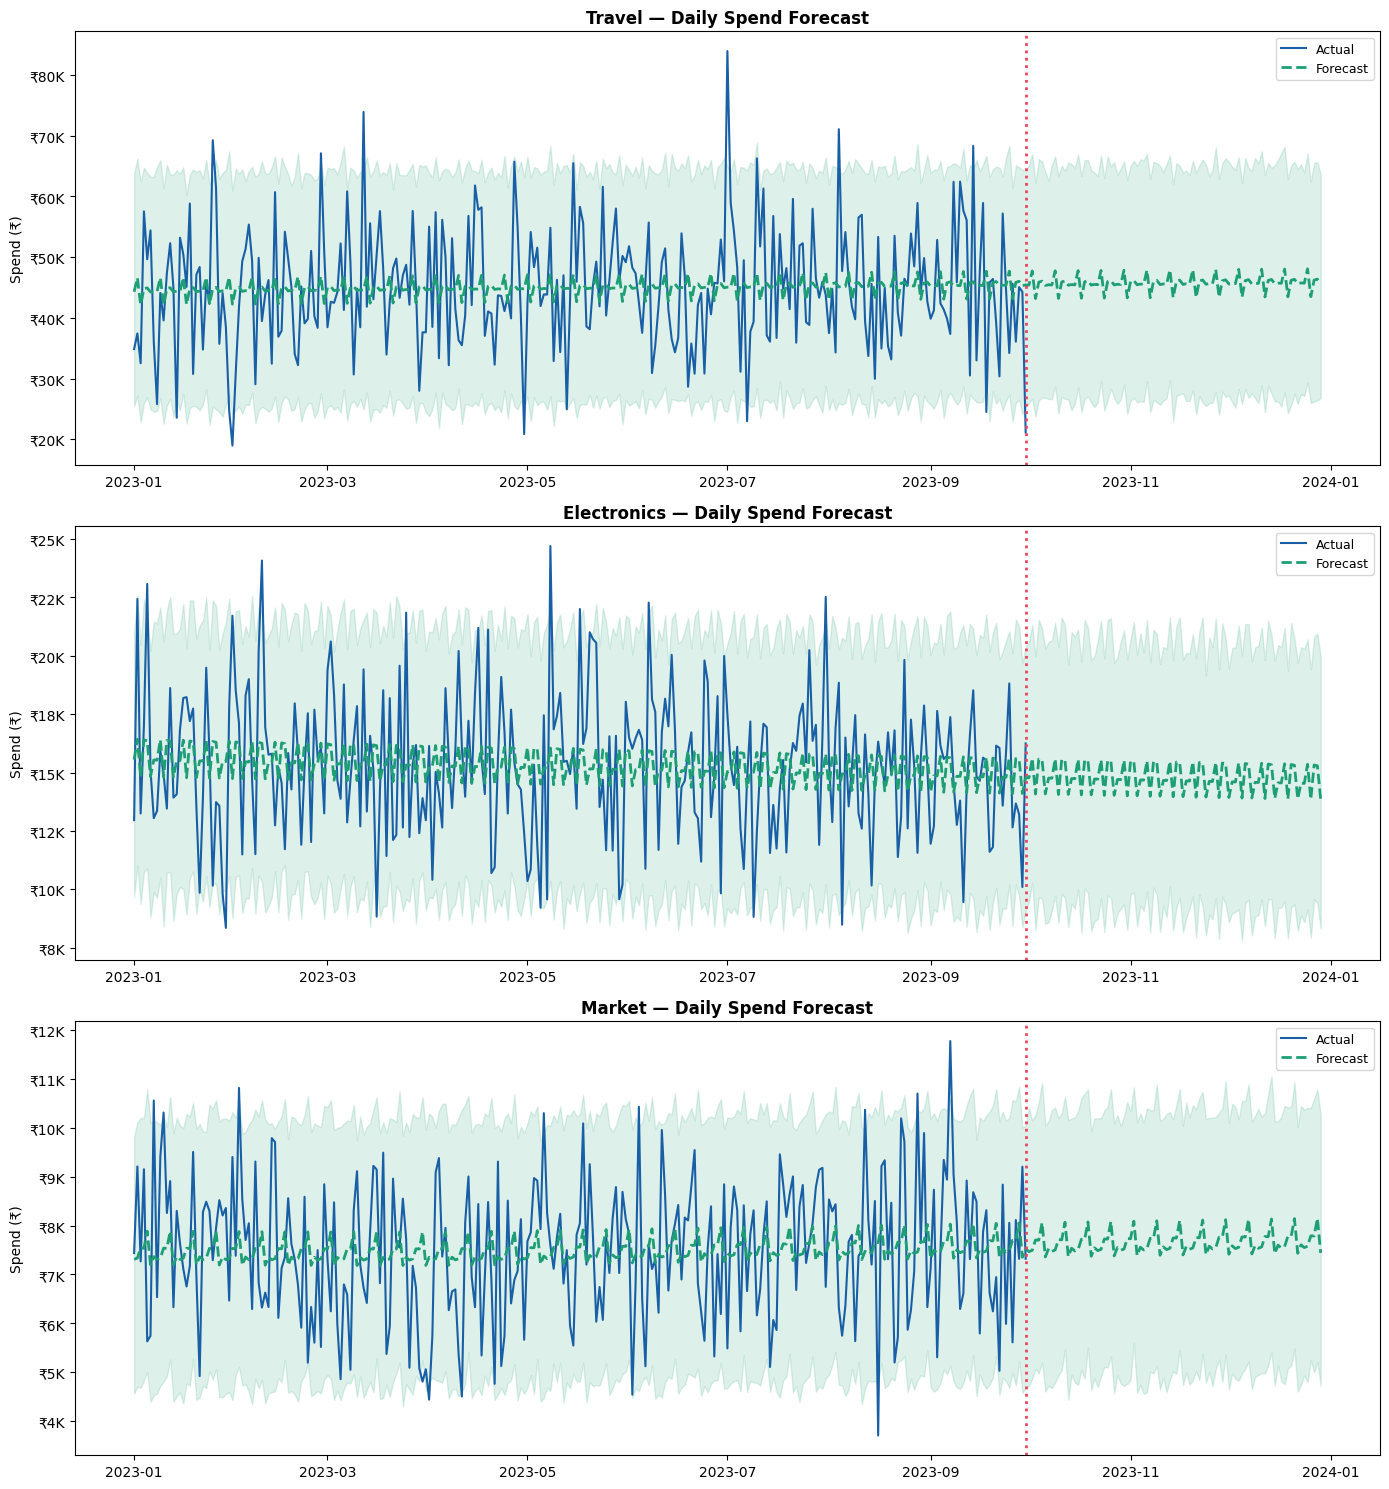


✅ Chart saved → screenshots/10_category_forecasts.png


In [6]:
categories = ['Travel', 'Electronics', 'Market']
category_forecasts = {}

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

for i, cat in enumerate(categories):
    # Prepare category data
    cat_daily = (df[df['category'] == cat]
                 .groupby('date')['transaction_amount']
                 .sum()
                 .reset_index())
    cat_daily.columns = ['ds', 'y']
    cat_daily = cat_daily.sort_values('ds').reset_index(drop=True)

    # Train model
    m = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        interval_width=0.95
    )
    m.fit(cat_daily)

    # Forecast 90 days
    future_cat = m.make_future_dataframe(periods=90)
    fc = m.predict(future_cat)
    category_forecasts[cat] = fc

    # Plot
    axes[i].plot(cat_daily['ds'], cat_daily['y'],
                 color='#185FA5', linewidth=1.5, label='Actual')
    axes[i].plot(fc['ds'], fc['yhat'],
                 color='#1D9E75', linewidth=2, linestyle='--', label='Forecast')
    axes[i].fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
                         alpha=0.15, color='#1D9E75')
    axes[i].axvline(x=cat_daily['ds'].max(), color='#E94560',
                    linestyle=':', linewidth=2)
    axes[i].set_title(f'{cat} — Daily Spend Forecast', fontweight='bold')
    axes[i].set_ylabel('Spend (₹)')
    axes[i].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'₹{x/1e3:.0f}K'))
    axes[i].legend(fontsize=9)

    print(f"✅ {cat} model trained")

plt.tight_layout()
plt.savefig('../screenshots/10_category_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Chart saved → screenshots/10_category_forecasts.png")

In [7]:
# Export total forecast
forecast_export = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export.columns = ['date', 'forecast', 'forecast_lower', 'forecast_upper']
forecast_export['category'] = 'Total'
forecast_export['type'] = forecast_export['date'].apply(
    lambda x: 'Actual' if x <= daily_spend['ds'].max() else 'Forecast'
)

# Export category forecasts
cat_exports = []
for cat, fc in category_forecasts.items():
    temp = fc[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    temp.columns = ['date', 'forecast', 'forecast_lower', 'forecast_upper']
    temp['category'] = cat
    cat_daily = (df[df['category'] == cat]
                 .groupby('date')['transaction_amount']
                 .sum().reset_index())
    temp['type'] = temp['date'].apply(
        lambda x: 'Actual' if x <= pd.to_datetime(
            cat_daily['date'].max()) else 'Forecast'
    )
    cat_exports.append(temp)

# Combine all
all_forecasts = pd.concat([forecast_export] + cat_exports, ignore_index=True)
all_forecasts['date'] = pd.to_datetime(all_forecasts['date']).dt.date

# Save
all_forecasts.to_csv('../exports/forecasts.csv', index=False)

print(f"✅ Forecast exported → exports/forecasts.csv")
print(f"   Rows     : {len(all_forecasts):,}")
print(f"   Categories: {all_forecasts['category'].unique().tolist()}")
print(f"   Types     : {all_forecasts['type'].value_counts().to_dict()}")
all_forecasts.head(5)

✅ Forecast exported → exports/forecasts.csv
   Rows     : 1,452
   Categories: ['Total', 'Travel', 'Electronics', 'Market']
   Types     : {'Actual': 1092, 'Forecast': 360}


,date,forecast,forecast_lower,forecast_upper,category,type
0,2023-01-01,76338.645444,56941.119753,96171.879988,Total,Actual
1,2023-01-02,79318.518561,59303.041232,98485.061166,Total,Actual
2,2023-01-03,73482.630763,53426.388876,93572.275656,Total,Actual
3,2023-01-04,77926.177655,57368.771053,98426.761631,Total,Actual
4,2023-01-05,78145.555081,58492.071122,98827.929984,Total,Actual


In [8]:
# Monthly aggregated data — Power BI overview page
monthly_summary = (df.groupby(['year', 'month', 'month_name'])
                   .agg(
                       total_spend=('transaction_amount', 'sum'),
                       total_transactions=('transaction_amount', 'count'),
                       avg_transaction=('transaction_amount', 'mean'),
                       outlier_count=('is_outlier', 'sum')
                   )
                   .reset_index()
                   .sort_values(['year', 'month']))

monthly_summary['total_spend']       = monthly_summary['total_spend'].round(2)
monthly_summary['avg_transaction']   = monthly_summary['avg_transaction'].round(2)

# Category monthly breakdown
cat_monthly = (df.groupby(['month', 'month_name', 'category'])
               .agg(
                   total_spend=('transaction_amount', 'sum'),
                   transactions=('transaction_amount', 'count')
               )
               .reset_index()
               .sort_values(['month', 'total_spend'], ascending=[True, False]))

cat_monthly['total_spend'] = cat_monthly['total_spend'].round(2)

# Gender monthly breakdown  
gender_monthly = (df[df['gender'] != 'Unknown']
                  .groupby(['month', 'month_name', 'gender'])
                  .agg(total_spend=('transaction_amount', 'sum'),
                       transactions=('transaction_amount', 'count'))
                  .reset_index())

gender_monthly['total_spend'] = gender_monthly['total_spend'].round(2)

# Save all
monthly_summary.to_csv('../exports/monthly_summary.csv', index=False)
cat_monthly.to_csv('../exports/category_monthly.csv', index=False)
gender_monthly.to_csv('../exports/gender_monthly.csv', index=False)

# Also export clean transactions for Power BI
df.to_csv('../exports/transactions_clean.csv', index=False)

print("✅ All Power BI exports complete")
print(f"   exports/monthly_summary.csv   → {len(monthly_summary)} rows")
print(f"   exports/category_monthly.csv  → {len(cat_monthly)} rows")
print(f"   exports/gender_monthly.csv    → {len(gender_monthly)} rows")
print(f"   exports/transactions_clean.csv → {len(df):,} rows")
print(f"\n📁 exports/ folder ready for Power BI import")

✅ All Power BI exports complete
   exports/monthly_summary.csv   → 9 rows
   exports/category_monthly.csv  → 54 rows
   exports/gender_monthly.csv    → 18 rows
   exports/transactions_clean.csv → 47,606 rows

📁 exports/ folder ready for Power BI import


In [9]:
# Add day_sort to transactions export
day_map = {
    'Monday':1,'Tuesday':2,'Wednesday':3,
    'Thursday':4,'Friday':5,'Saturday':6,'Sunday':7
}
df['day_sort'] = df['day_of_week'].map(day_map)
df.to_csv('../exports/transactions_clean.csv', index=False)
print("✅ transactions_clean.csv updated with day_sort column")

✅ transactions_clean.csv updated with day_sort column
